In [ ]:
# ============================================================
# QUICKCART WAREHOUSE INVENTORY STOCKOUT RISK
# END-TO-END MACHINE LEARNING PROJECT
# ============================================================

# ============================================================
# 1. IMPORT LIBRARIES
# ============================================================

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay
)

import joblib

pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)

In [ ]:
# ============================================================
# 2. LOAD DATA
# ============================================================

stores = pd.read_csv("dim_stores.csv")
skus = pd.read_csv("dim_skus.csv")
suppliers = pd.read_csv("dim_suppliers.csv")
events = pd.read_csv("dim_events.csv")
inventory = pd.read_csv("fact_inventory_daily.csv")

print("Stores:", stores.shape)
print("SKUs:", skus.shape)
print("Suppliers:", suppliers.shape)
print("Events:", events.shape)
print("Inventory:", inventory.shape)

Stores: (12, 8)
SKUs: (60, 9)
Suppliers: (15, 6)
Events: (30, 5)
Inventory: (21600, 16)


In [ ]:
# ============================================================
# 3. BASIC INSPECTION
# ============================================================

datasets = {
    "stores": stores,
    "skus": skus,
    "suppliers": suppliers,
    "events": events,
    "inventory": inventory
}

for name, df in datasets.items():

    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)

    print("Shape:", df.shape)

    print("\nColumns:")
    print(df.columns.tolist())

    print("\nMissing values:")
    print(df.isnull().sum())

    print("\nDuplicate rows:", df.duplicated().sum())


STORES
Shape: (12, 8)

Columns:
['store_id', 'city', 'city_display', 'city_tier', 'store_size', 'sqft', 'opened_year', 'baseline_daily_orders']

Missing values:
store_id                 0
city                     0
city_display             0
city_tier                0
store_size               0
sqft                     0
opened_year              0
baseline_daily_orders    0
dtype: int64

Duplicate rows: 0

SKUS
Shape: (60, 9)

Columns:
['sku_id', 'sku_name', 'category', 'unit_price_inr', 'shelf_life_days', 'is_perishable', 'festive_relevant', 'popularity_tier', 'supplier_id']

Missing values:
sku_id              0
sku_name            0
category            0
unit_price_inr      0
shelf_life_days     0
is_perishable       0
festive_relevant    0
popularity_tier     0
supplier_id         0
dtype: int64

Duplicate rows: 0

SUPPLIERS
Shape: (15, 6)

Columns:
['supplier_id', 'supplier_name', 'categories_supplied', 'reliability_score', 'base_lead_time_days', 'lead_time_variance_days']

Missi

In [ ]:
# ============================================================
# 4. DATE CONVERSION
# ============================================================

events["date"] = pd.to_datetime(events["date"])
inventory["date"] = pd.to_datetime(inventory["date"])

print(inventory["date"].min())
print(inventory["date"].max())

2026-10-01 00:00:00
2026-10-30 00:00:00


In [ ]:
# ============================================================
# 5. CLEAN CITY DISPLAY
# ============================================================

stores["city_display"] = (
    stores["city_display"]
    .astype(str)
    .str.strip()
    .str.title()
)

print(stores[["city", "city_display"]])

         city city_display
0      Mumbai       Mumbai
1      Mumbai       Mumbai
2   Bengaluru    Bengaluru
3   Bengaluru    Bengaluru
4       Delhi        Delhi
5       Delhi        Delhi
6        Pune         Pune
7        Pune         Pune
8   Hyderabad    Hyderabad
9   Hyderabad    Hyderabad
10    Chennai      Chennai
11    Chennai      Chennai


In [ ]:
# ============================================================
# 6. CLEAN SUPPLIER RELIABILITY
# ============================================================

suppliers["reliability_score"] = pd.to_numeric(
    suppliers["reliability_score"],
    errors="coerce"
)

print(
    "Missing reliability scores:",
    suppliers["reliability_score"].isna().sum()
)

Missing reliability scores: 3


In [ ]:
# ============================================================
# 7. CATEGORY-BASED RELIABILITY IMPUTATION
# ============================================================

# Expand supplier categories

supplier_categories = suppliers[
    ["supplier_id", "categories_supplied", "reliability_score"]
].copy()

supplier_categories["category"] = (
    supplier_categories["categories_supplied"]
    .str.split(",")
)

supplier_categories = supplier_categories.explode("category")

supplier_categories["category"] = (
    supplier_categories["category"]
    .str.strip()
)

category_median_reliability = (
    supplier_categories
    .groupby("category")["reliability_score"]
    .median()
)

print(category_median_reliability)

category
Bakery                 0.645
Beverages              0.665
Dairy                  0.700
Fruits & Vegetables    0.830
Home Care              0.665
Personal Care          0.690
Snacks                 0.865
Staples                0.910
Name: reliability_score, dtype: float64


In [ ]:
# ============================================================
# 8. IMPUTE MISSING SUPPLIER RELIABILITY
# ============================================================

supplier_categories = supplier_categories.merge(
    category_median_reliability.rename("category_median_reliability"),
    on="category",
    how="left"
)

supplier_categories["reliability_clean"] = (
    supplier_categories["reliability_score"]
    .fillna(supplier_categories["category_median_reliability"])
)

supplier_reliability = (
    supplier_categories
    .groupby("supplier_id")["reliability_clean"]
    .mean()
)

suppliers["reliability_score_clean"] = (
    suppliers["supplier_id"]
    .map(supplier_reliability)
)

print(
    suppliers[
        [
            "supplier_id",
            "reliability_score",
            "reliability_score_clean"
        ]
    ]
)

   supplier_id  reliability_score  reliability_score_clean
0        SUP01               0.92                   0.9200
1        SUP02               0.93                   0.9300
2        SUP03               0.90                   0.9000
3        SUP04               0.70                   0.7000
4        SUP05               0.66                   0.6600
5        SUP06                NaN                   0.6775
6        SUP07               0.67                   0.6700
7        SUP08               0.73                   0.7300
8        SUP09               0.72                   0.7200
9        SUP10               0.66                   0.6600
10       SUP11               0.83                   0.8300
11       SUP12               0.63                   0.6300
12       SUP13               0.91                   0.9100
13       SUP14                NaN                   0.9100
14       SUP15                NaN                   0.6650


In [ ]:
# ============================================================
# 9. VALIDATE FACT TABLE GRAIN
# ============================================================

duplicate_grain = inventory.duplicated(
    subset=["store_id", "sku_id", "date"]
).sum()

print("Duplicate Store-SKU-Date combinations:", duplicate_grain)

expected_rows = 12 * 60 * 30

print("Expected rows:", expected_rows)
print("Actual rows:", len(inventory))

Duplicate Store-SKU-Date combinations: 0
Expected rows: 21600
Actual rows: 21600


In [ ]:
# ============================================================
# 10. MERGE DATASETS
# ============================================================

df = inventory.copy()

# Store information
df = df.merge(
    stores,
    on="store_id",
    how="left",
    validate="many_to_one"
)

# SKU information
df = df.merge(
    skus,
    on="sku_id",
    how="left",
    suffixes=("", "_sku"),
    validate="many_to_one"
)

# Supplier information
df = df.merge(
    suppliers[
        [
            "supplier_id",
            "supplier_name",
            "categories_supplied",
            "reliability_score_clean",
            "base_lead_time_days",
            "lead_time_variance_days"
        ]
    ],
    on="supplier_id",
    how="left",
    validate="many_to_one"
)

# Event information
df = df.merge(
    events,
    on="date",
    how="left",
    validate="many_to_one"
)

print("Final shape:", df.shape)

Final shape: (21600, 40)


In [ ]:
# ============================================================
# 11. JOIN VALIDATION
# ============================================================

print("Rows before joins:", len(inventory))
print("Rows after joins:", len(df))

assert len(df) == len(inventory), \
    "ERROR: Join multiplied the number of rows!"

print("Join validation passed.")

Rows before joins: 21600
Rows after joins: 21600
Join validation passed.


In [ ]:
# ============================================================
# 12. SORT DATA
# ============================================================

df = df.sort_values(
    ["store_id", "sku_id", "date"]
).reset_index(drop=True)

In [ ]:
# ============================================================
# 13. FEATURE ENGINEERING
# ============================================================

group_cols = ["store_id", "sku_id"]

# ------------------------------------------------------------
# Historical sales features
# ------------------------------------------------------------

df["sales_velocity_3d_lag"] = (
    df.groupby(group_cols)["units_sold"]
      .transform(
          lambda x: x.shift(1).rolling(3, min_periods=1).mean()
      )
)

df["sales_velocity_7d_lag"] = (
    df.groupby(group_cols)["units_sold"]
      .transform(
          lambda x: x.shift(1).rolling(7, min_periods=1).mean()
      )
)

# ------------------------------------------------------------
# Historical stock
# ------------------------------------------------------------

df["previous_closing_stock"] = (
    df.groupby(group_cols)["closing_stock"]
      .shift(1)
)

# ------------------------------------------------------------
# Historical demand
# ------------------------------------------------------------

df["previous_units_demanded"] = (
    df.groupby(group_cols)["units_demanded"]
      .shift(1)
)

# ------------------------------------------------------------
# Historical reorder
# ------------------------------------------------------------

df["previous_reorder_placed"] = (
    df.groupby(group_cols)["reorder_placed"]
      .shift(1)
)

# ------------------------------------------------------------
# Reorder frequency
# ------------------------------------------------------------

df["reorders_last_7d"] = (
    df.groupby(group_cols)["reorder_placed"]
      .transform(
          lambda x:
          x.shift(1)
           .eq("Y")
           .rolling(7, min_periods=1)
           .sum()
      )
)

# ------------------------------------------------------------
# Recent stockout history
# ------------------------------------------------------------

df["previous_stockout_risk"] = (
    df.groupby(group_cols)["stockout_risk"]
      .shift(1)
)

df["previous_imminent"] = (
    df["previous_stockout_risk"]
    .eq("Imminent")
    .astype(int)
)

# ------------------------------------------------------------
# Date features
# ------------------------------------------------------------

df["day_of_month"] = df["date"].dt.day

df["day_of_week"] = df["date"].dt.dayofweek

df["is_weekend"] = (
    df["day_of_week"] >= 5
).astype(int)

# ------------------------------------------------------------
# Festival timing
# ------------------------------------------------------------

df["is_festival_week_num"] = (
    df["is_festival_week"]
    .map({"Y": 1, "N": 0})
    .fillna(0)
)

# ------------------------------------------------------------
# Store demand share
# ------------------------------------------------------------

total_baseline_orders = stores["baseline_daily_orders"].sum()

df["store_demand_share"] = (
    df["baseline_daily_orders"]
    / total_baseline_orders
)

# ------------------------------------------------------------
# Reorder gap
# ------------------------------------------------------------

df["reorder_gap"] = (
    df["reorder_point"]
    - df["closing_stock"]
)

# ------------------------------------------------------------
# Expected lead-time pressure
# ------------------------------------------------------------

df["historical_cover_pressure"] = (
    df["sales_velocity_7d_lag"]
    / df["lead_time_days_expected"].replace(0, np.nan)
)

In [ ]:
# ============================================================
# 14. REMOVE LEAKAGE / NON-PREDICTIVE COLUMNS
# ============================================================

target = "stockout_risk"

leakage_columns = [
    "stockout_risk",
    "days_of_cover",
    "sales_velocity_7d",

    # Current-day operational values that directly define the
    # current target should not be used as predictors.
    "lead_time_days_actual"
]

df_model = df.drop(
    columns=leakage_columns,
    errors="ignore"
).copy()

In [ ]:
# ============================================================
# 15. REMOVE INITIAL HISTORY ROWS
# ============================================================

df_model = df_model[
    df_model["previous_closing_stock"].notna()
].copy()

print("Rows available for modeling:", len(df_model))

Rows available for modeling: 20880


In [ ]:
# ============================================================
# 16. FEATURE SELECTION
# ============================================================
features = [
    # Inventory
    "opening_stock",
    "closing_stock",
    "units_demanded",
    "units_sold",
    "reorder_point",
    "reorder_gap",

    # Historical behavior
    "previous_closing_stock",
    "previous_units_demanded",
    "sales_velocity_3d_lag",
    "sales_velocity_7d_lag",
    "reorders_last_7d",
    "previous_imminent",

    # Replenishment
    "lead_time_days_expected",
    "base_lead_time_days",
    "lead_time_variance_days",

    # Supplier
    "reliability_score_clean",

    # Product
    "unit_price_inr",
    "shelf_life_days",

    # Store
    "sqft",
    "baseline_daily_orders",
    "store_demand_share",

    # Time
    "day_of_month",
    "day_of_week",
    "is_weekend",
    "is_festival_week_num",

    # Event
    "demand_multiplier_festive",
    "demand_multiplier_other",

    # Pressure
    "historical_cover_pressure",

    # Categories
    "category",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "store_size",
    "event_type"
]

X = df_model[features].copy()
y = df.loc[df_model.index, target].copy()

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (20880, 34)
y shape: (20880,)


In [ ]:
# ============================================================
# 17. CATEGORICAL / NUMERICAL FEATURES
# ============================================================

categorical_features = [
    "category",
    "is_perishable",
    "festive_relevant",
    "popularity_tier",
    "store_size",
    "event_type"
]

numeric_features = [
    col for col in features
    if col not in categorical_features
]

print("Numerical features:", len(numeric_features))
print("Categorical features:", len(categorical_features))

Numerical features: 28
Categorical features: 6


In [ ]:
# ============================================================
# 18. TIME-BASED TRAIN / TEST SPLIT
# ============================================================

train_end_date = pd.Timestamp("2026-10-23")

train_mask = df_model["date"] <= train_end_date
test_mask = df_model["date"] > train_end_date

X_train = X.loc[train_mask]
X_test = X.loc[test_mask]

y_train = y.loc[train_mask]
y_test = y.loc[test_mask]

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))

print("\nTraining dates:")
print(
    df_model.loc[train_mask, "date"].min(),
    "to",
    df_model.loc[train_mask, "date"].max()
)

print("\nTesting dates:")
print(
    df_model.loc[test_mask, "date"].min(),
    "to",
    df_model.loc[test_mask, "date"].max()
)

Training rows: 15840
Testing rows: 5040

Training dates:
2026-10-02 00:00:00 to 2026-10-23 00:00:00

Testing dates:
2026-10-24 00:00:00 to 2026-10-30 00:00:00


In [ ]:
# ============================================================
# 19. CLASS DISTRIBUTION
# ============================================================

print("Training distribution:")
print(
    y_train.value_counts(normalize=True)
)

print("\nTesting distribution:")
print(
    y_test.value_counts(normalize=True)
)

Training distribution:
stockout_risk
Safe        0.657197
At-Risk     0.249432
Imminent    0.093371
Name: proportion, dtype: float64

Testing distribution:
stockout_risk
Safe        0.622817
At-Risk     0.223413
Imminent    0.153770
Name: proportion, dtype: float64


In [ ]:
# ============================================================
# 20. PREPROCESSING PIPELINE
# ============================================================

preprocessor = ColumnTransformer(
    transformers=[
        (
            "numeric",
            StandardScaler(),
            numeric_features
        ),
        (
            "categorical",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [ ]:
# ============================================================
# 21. MAJORITY CLASS BASELINE
# ============================================================

majority_class = y_train.mode()[0]

baseline_predictions = np.full(
    len(y_test),
    majority_class
)

print("Majority class:", majority_class)

print(
    classification_report(
        y_test,
        baseline_predictions,
        zero_division=0
    )
)

Majority class: Safe
              precision    recall  f1-score   support

     At-Risk       0.00      0.00      0.00      1126
    Imminent       0.00      0.00      0.00       775
        Safe       0.62      1.00      0.77      3139

    accuracy                           0.62      5040
   macro avg       0.21      0.33      0.26      5040
weighted avg       0.39      0.62      0.48      5040



In [ ]:
# ============================================================
# 22. LOGISTIC REGRESSION
# ============================================================

logistic_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            LogisticRegression(
                max_iter=2000,
                class_weight="balanced",
                random_state=42
            )
        )
    ]
)

logistic_model.fit(
    X_train,
    y_train
)

logistic_pred = logistic_model.predict(
    X_test
)

In [ ]:
# ============================================================
# 23. LOGISTIC REGRESSION EVALUATION
# ============================================================

print("LOGISTIC REGRESSION")
print("=" * 60)

print(
    classification_report(
        y_test,
        logistic_pred,
        zero_division=0
    )
)

logistic_accuracy = accuracy_score(
    y_test,
    logistic_pred
)

logistic_macro_f1 = f1_score(
    y_test,
    logistic_pred,
    average="macro"
)

logistic_imminent_recall = recall_score(
    y_test,
    logistic_pred,
    labels=["Imminent"],
    average=None,
    zero_division=0
)[0]

print("Accuracy:", logistic_accuracy)
print("Macro F1:", logistic_macro_f1)
print("Imminent Recall:", logistic_imminent_recall)

LOGISTIC REGRESSION
              precision    recall  f1-score   support

     At-Risk       0.86      0.57      0.69      1126
    Imminent       0.64      0.89      0.75       775
        Safe       0.95      0.97      0.96      3139

    accuracy                           0.87      5040
   macro avg       0.82      0.81      0.80      5040
weighted avg       0.88      0.87      0.87      5040

Accuracy: 0.8706349206349207
Macro F1: 0.7980406075968668
Imminent Recall: 0.8903225806451613


In [ ]:
# ============================================================
# 24. RANDOM FOREST
# ============================================================

random_forest_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            RandomForestClassifier(
                n_estimators=400,
                max_depth=15,
                min_samples_leaf=3,
                class_weight="balanced",
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

random_forest_model.fit(
    X_train,
    y_train
)

rf_pred = random_forest_model.predict(
    X_test
)

In [ ]:
# ============================================================
# 25. RANDOM FOREST EVALUATION
# ============================================================

print("RANDOM FOREST")
print("=" * 60)

print(
    classification_report(
        y_test,
        rf_pred,
        zero_division=0
    )
)

rf_accuracy = accuracy_score(
    y_test,
    rf_pred
)

rf_macro_f1 = f1_score(
    y_test,
    rf_pred,
    average="macro"
)

rf_imminent_recall = recall_score(
    y_test,
    rf_pred,
    labels=["Imminent"],
    average=None,
    zero_division=0
)[0]

print("Accuracy:", rf_accuracy)
print("Macro F1:", rf_macro_f1)
print("Imminent Recall:", rf_imminent_recall)

RANDOM FOREST
              precision    recall  f1-score   support

     At-Risk       0.79      0.63      0.70      1126
    Imminent       0.90      0.78      0.84       775
        Safe       0.90      0.99      0.94      3139

    accuracy                           0.88      5040
   macro avg       0.86      0.80      0.83      5040
weighted avg       0.87      0.88      0.87      5040

Accuracy: 0.878968253968254
Macro F1: 0.8256269220789733
Imminent Recall: 0.7806451612903226


In [ ]:
# ============================================================
# 26. GRADIENT BOOSTING
# ============================================================

gradient_boosting_model = Pipeline(
    steps=[
        ("preprocessor", preprocessor),

        (
            "classifier",
            GradientBoostingClassifier(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=4,
                random_state=42
            )
        )
    ]
)

gradient_boosting_model.fit(
    X_train,
    y_train
)

gb_pred = gradient_boosting_model.predict(
    X_test
)

In [ ]:
# ============================================================
# 27. GRADIENT BOOSTING EVALUATION
# ============================================================

print("GRADIENT BOOSTING")
print("=" * 60)

print(
    classification_report(
        y_test,
        gb_pred,
        zero_division=0
    )
)

gb_accuracy = accuracy_score(
    y_test,
    gb_pred
)

gb_macro_f1 = f1_score(
    y_test,
    gb_pred,
    average="macro"
)

gb_imminent_recall = recall_score(
    y_test,
    gb_pred,
    labels=["Imminent"],
    average=None,
    zero_division=0
)[0]

print("Accuracy:", gb_accuracy)
print("Macro F1:", gb_macro_f1)
print("Imminent Recall:", gb_imminent_recall)

GRADIENT BOOSTING
              precision    recall  f1-score   support

     At-Risk       0.79      0.62      0.69      1126
    Imminent       0.91      0.77      0.83       775
        Safe       0.89      1.00      0.94      3139

    accuracy                           0.88      5040
   macro avg       0.86      0.79      0.82      5040
weighted avg       0.87      0.88      0.87      5040

Accuracy: 0.876984126984127
Macro F1: 0.8225057724681202
Imminent Recall: 0.7651612903225806


In [ ]:
# ============================================================
# 28. MODEL COMPARISON
# ============================================================

results = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],

    "Accuracy": [
        accuracy_score(y_test, baseline_predictions),
        logistic_accuracy,
        rf_accuracy,
        gb_accuracy
    ],

    "Macro F1": [
        f1_score(
            y_test,
            baseline_predictions,
            average="macro"
        ),

        logistic_macro_f1,
        rf_macro_f1,
        gb_macro_f1
    ],

    "Imminent Recall": [
        recall_score(
            y_test,
            baseline_predictions,
            labels=["Imminent"],
            average=None,
            zero_division=0
        )[0],

        logistic_imminent_recall,
        rf_imminent_recall,
        gb_imminent_recall
    ]
})

print(
    results.sort_values(
        "Imminent Recall",
        ascending=False
    )
)

                 Model  Accuracy  Macro F1  Imminent Recall
1  Logistic Regression  0.870635  0.798041         0.890323
2        Random Forest  0.878968  0.825627         0.780645
3    Gradient Boosting  0.876984  0.822506         0.765161
0    Majority Baseline  0.622817  0.255858         0.000000


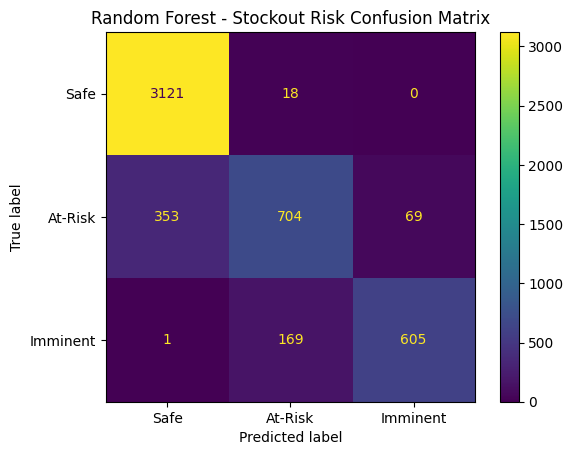

In [ ]:
# ============================================================
# 29. RANDOM FOREST CONFUSION MATRIX
# ============================================================

cm = confusion_matrix(
    y_test,
    rf_pred,
    labels=[
        "Safe",
        "At-Risk",
        "Imminent"
    ]
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=[
        "Safe",
        "At-Risk",
        "Imminent"
    ]
)

disp.plot()

plt.title("Random Forest - Stockout Risk Confusion Matrix")
plt.show()

In [ ]:
# ============================================================
# 30. RANDOM FOREST FEATURE IMPORTANCE
# ============================================================

rf_preprocessor = (
    random_forest_model
    .named_steps["preprocessor"]
)

rf_classifier = (
    random_forest_model
    .named_steps["classifier"]
)

feature_names = (
    rf_preprocessor
    .get_feature_names_out()
)

importance = pd.DataFrame({
    "feature": feature_names,
    "importance": rf_classifier.feature_importances_
})

importance = importance.sort_values(
    "importance",
    ascending=False
)

print(
    importance.head(20)
)

                               feature  importance
5                 numeric__reorder_gap    0.326533
11          numeric__previous_imminent    0.149635
1               numeric__closing_stock    0.101298
6      numeric__previous_closing_stock    0.047316
0               numeric__opening_stock    0.041933
9       numeric__sales_velocity_7d_lag    0.031327
4               numeric__reorder_point    0.030179
8       numeric__sales_velocity_3d_lag    0.026756
2              numeric__units_demanded    0.023254
3                  numeric__units_sold    0.023218
27  numeric__historical_cover_pressure    0.022295
10           numeric__reorders_last_7d    0.021395
7     numeric__previous_units_demanded    0.016430
15    numeric__reliability_score_clean    0.016329
14    numeric__lead_time_variance_days    0.013266
21               numeric__day_of_month    0.012371
13        numeric__base_lead_time_days    0.011428
12    numeric__lead_time_days_expected    0.010361
17            numeric__shelf_li

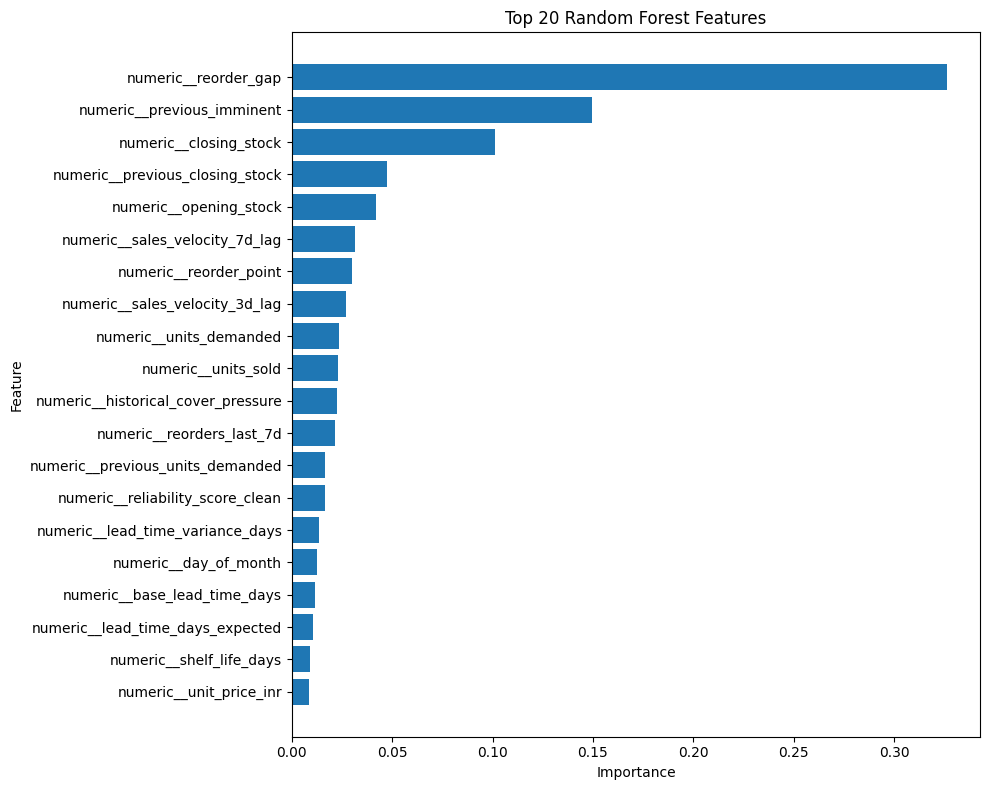

In [ ]:
# ============================================================
# 31. TOP 20 FEATURE IMPORTANCE
# ============================================================

top_features = importance.head(20).sort_values(
    "importance"
)

plt.figure(figsize=(10, 8))

plt.barh(
    top_features["feature"],
    top_features["importance"]
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top 20 Random Forest Features")

plt.tight_layout()
plt.show()

In [ ]:
# ============================================================
# 32. SELECT FINAL MODEL
# ============================================================

model_scores = {
    "Logistic Regression": {
        "model": logistic_model,
        "imminent_recall": logistic_imminent_recall,
        "macro_f1": logistic_macro_f1
    },

    "Random Forest": {
        "model": random_forest_model,
        "imminent_recall": rf_imminent_recall,
        "macro_f1": rf_macro_f1
    },

    "Gradient Boosting": {
        "model": gradient_boosting_model,
        "imminent_recall": gb_imminent_recall,
        "macro_f1": gb_macro_f1
    }
}

for name, score in model_scores.items():

    print(
        f"{name}: "
        f"Imminent Recall = {score['imminent_recall']:.4f}, "
        f"Macro F1 = {score['macro_f1']:.4f}"
    )

Logistic Regression: Imminent Recall = 0.8903, Macro F1 = 0.7980
Random Forest: Imminent Recall = 0.7806, Macro F1 = 0.8256
Gradient Boosting: Imminent Recall = 0.7652, Macro F1 = 0.8225


In [ ]:
# ============================================================
# 33. SAVE FINAL MODEL
# ============================================================

final_model = random_forest_model

joblib.dump(
    final_model,
    "quickcart_stockout_risk_model.pkl"
)

print("Model saved successfully.")

Model saved successfully.


In [ ]:
# ============================================================
# 34. LOAD SAVED MODEL
# ============================================================

loaded_model = joblib.load(
    "quickcart_stockout_risk_model.pkl"
)

print("Model loaded successfully.")

Model loaded successfully.


In [ ]:
# ============================================================
# 35. PREDICTION OUTPUT
# ============================================================

# Columns to include in the prediction output, excluding 'stockout_risk' for now
cols_for_output = [
    "date",
    "store_id",
    "sku_id",
    "category",
    "closing_stock",
    "lead_time_days_expected"
]

# Create prediction_output from df_model with available columns
prediction_output = df_model.loc[
    test_mask,
    cols_for_output
].copy()

# Add the true 'stockout_risk' values from y_test
prediction_output["stockout_risk"] = y_test

prediction_output["predicted_risk"] = final_model.predict(
    X_test
)

prediction_output["prediction_correct"] = (
    prediction_output["stockout_risk"]
    == prediction_output["predicted_risk"]
)

print(
    prediction_output.head(20)
)

         date store_id  sku_id             category  closing_stock  lead_time_days_expected stockout_risk  \
23 2026-10-24     ST01  SKU001  Fruits & Vegetables           34.8                        1       At-Risk   
24 2026-10-25     ST01  SKU001  Fruits & Vegetables          188.8                        1          Safe   
25 2026-10-26     ST01  SKU001  Fruits & Vegetables          162.8                        1          Safe   
26 2026-10-27     ST01  SKU001  Fruits & Vegetables          148.8                        1          Safe   
27 2026-10-28     ST01  SKU001  Fruits & Vegetables          131.8                        1          Safe   
28 2026-10-29     ST01  SKU001  Fruits & Vegetables          112.8                        1          Safe   
29 2026-10-30     ST01  SKU001  Fruits & Vegetables           99.8                        1          Safe   
53 2026-10-24     ST01  SKU002  Fruits & Vegetables           51.5                        2       At-Risk   
54 2026-10-25     S

In [ ]:
# ============================================================
# 36. PREDICTION PROBABILITIES
# ============================================================

probabilities = final_model.predict_proba(
    X_test
)

classes = final_model.classes_

probability_df = pd.DataFrame(
    probabilities,
    columns=[
        f"prob_{c}"
        for c in classes
    ],
    index=X_test.index
)

prediction_output = pd.concat(
    [
        prediction_output,
        probability_df
    ],
    axis=1
)

print(
    prediction_output.head(20)
)

         date store_id  sku_id             category  closing_stock  lead_time_days_expected stockout_risk  \
23 2026-10-24     ST01  SKU001  Fruits & Vegetables           34.8                        1       At-Risk   
24 2026-10-25     ST01  SKU001  Fruits & Vegetables          188.8                        1          Safe   
25 2026-10-26     ST01  SKU001  Fruits & Vegetables          162.8                        1          Safe   
26 2026-10-27     ST01  SKU001  Fruits & Vegetables          148.8                        1          Safe   
27 2026-10-28     ST01  SKU001  Fruits & Vegetables          131.8                        1          Safe   
28 2026-10-29     ST01  SKU001  Fruits & Vegetables          112.8                        1          Safe   
29 2026-10-30     ST01  SKU001  Fruits & Vegetables           99.8                        1          Safe   
53 2026-10-24     ST01  SKU002  Fruits & Vegetables           51.5                        2       At-Risk   
54 2026-10-25     S

In [ ]:
# ============================================================
# 37. HIGH-RISK INVENTORY
# ============================================================

high_risk = prediction_output[
    prediction_output["predicted_risk"] == "Imminent"
].copy()

high_risk = high_risk.sort_values(
    "prob_Imminent",
    ascending=False
)

print(
    high_risk.head(20)
)

            date store_id  sku_id             category  closing_stock  lead_time_days_expected stockout_risk  \
20484 2026-10-25     ST12  SKU023               Snacks            0.0                        5      Imminent   
9778  2026-10-29     ST06  SKU026            Beverages            8.0                        1      Imminent   
1944  2026-10-25     ST02  SKU005  Fruits & Vegetables            0.0                        2      Imminent   
10733 2026-10-24     ST06  SKU058               Bakery            0.0                        4      Imminent   
19163 2026-10-24     ST11  SKU039        Personal Care            0.0                        4      Imminent   
16884 2026-10-25     ST10  SKU023               Snacks            0.0                        5      Imminent   
5243  2026-10-24     ST03  SKU055               Bakery            0.0                        4      Imminent   
264   2026-10-25     ST01  SKU009  Fruits & Vegetables            0.0                        2      Immi

In [ ]:
# ============================================================
# 38. EXPORT RESULTS
# ============================================================

prediction_output.to_csv(
    "quickcart_stockout_predictions.csv",
    index=False
)

high_risk.to_csv(
    "quickcart_high_risk_inventory.csv",
    index=False
)

print("Prediction files exported.")

Prediction files exported.
